In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error, mean_absolute_error, r2_score
)

In [8]:
# Calculamos las métricas de evaluación
def calcular_metricas_evaluacion(y_prediccion: np.ndarray, y_real: np.ndarray, verbose: bool = True):
    """Calcula las métricas de evaluación para un modelo de regresión.
    
    Calcula cuatro métricas comunes para evaluar modelos de regresión: MSE (Error Cuadrático Medio),
    RMSE (Raíz del Error Cuadrático Medio), MAE (Error Absoluto Medio) y R² (Coeficiente de determinación).
    Opcionalmente imprime los resultados en un formato legible.
    
    Args:
        y_prediccion (np.ndarray): Valores predichos por el modelo.
        y_real (np.ndarray): Valores reales observados.
        verbose (bool, optional): Si es True, imprime las métricas calculadas. Por defecto es True.
    
    Returns:
        tuple[float, float, float, float]: Una tupla con cuatro valores en el siguiente orden:
            - mse: Error cuadrático medio.
            - rmse: Raíz del error cuadrático medio.
            - mae: Error absoluto medio.
            - r2: Coeficiente de determinación.
    
    Example:
        >>> mse, rmse, mae, r2 = calcular_metricas_evaluacion(modelo.predict(X_test), y_test)
        >>> print(f"R²: {r2:.4f}")
    """
    
    mse = mean_squared_error(y_real, y_prediccion)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_prediccion)
    r2 = r2_score(y_real, y_prediccion)

    if verbose:
        print("\nEvaluación del modelo:")
        print(f"MSE (Error cuadrático medio): {mse:.4f}")
        print(f"RMSE (Raíz del error cuadrático medio): {rmse:.4f}")
        print(f"MAE (Error absoluto medio): {mae:.4f}")
        print(f"R² (Coeficiente de determinación): {r2:.4f}")
        print(f"El modelo explica aproximadamente el {r2:.2%} de la varianza")
    
    return mse, rmse, mae, r2

In [9]:
df = pd.read_csv("../../data/processed/dataset_practica_final_preprocessed.csv")

target_column = 'is_canceled'
    
# Eliminamos la columna is_canceled de las variables independientes
# Y transformamos a numérico la columna is_canceled
X_hotel = df.drop(columns=target_column)
y_hotel = df[target_column].astype(int)

# Hacemos un train-test split
X_train, X_test, y_train, y_test = train_test_split(X_hotel, y_hotel, test_size=0.2, random_state=42)

In [10]:
# Inicializamos el modelo de Random Forest Classifier y lo entrenamos con los datos de entrenamiento
modelo_rfc = RandomForestClassifier(n_estimators=150, max_depth=3, random_state=42)
modelo_rfc.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_rfc.predict(X_test)

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")

mse, rmse, mae, r2 = calcular_metricas_evaluacion(y_pred, y_test)

Accuracy:  0.76
Precisión: 0.99
Recall:    0.36
F1-Score:  0.53

Evaluación del modelo:
MSE (Error cuadrático medio): 0.2403
RMSE (Raíz del error cuadrático medio): 0.4902
MAE (Error absoluto medio): 0.2403
R² (Coeficiente de determinación): -0.0244
El modelo explica aproximadamente el -2.44% de la varianza


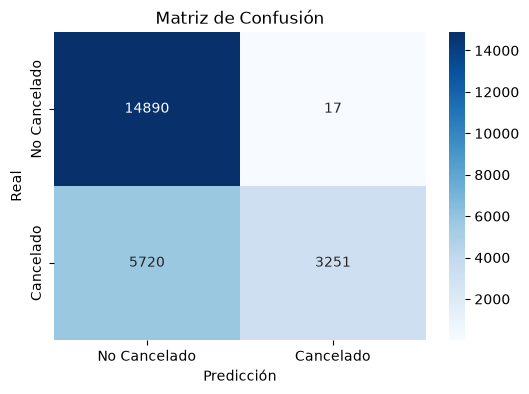

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Cancelado', 'Cancelado'],
            yticklabels=['No Cancelado', 'Cancelado'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

In [12]:
# Inicializamos el modelo de árbol de decisión y lo entrenamos con los datos de entrenamiento
modelo_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_dt.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_dt.predict(X_test)

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")

mse, rmse, mae, r2 = calcular_metricas_evaluacion(y_pred, y_test)

Accuracy:  0.77
Precisión: 0.99
Recall:    0.38
F1-Score:  0.55

Evaluación del modelo:
MSE (Error cuadrático medio): 0.2339
RMSE (Raíz del error cuadrático medio): 0.4836
MAE (Error absoluto medio): 0.2339
R² (Coeficiente de determinación): 0.0028
El modelo explica aproximadamente el 0.28% de la varianza


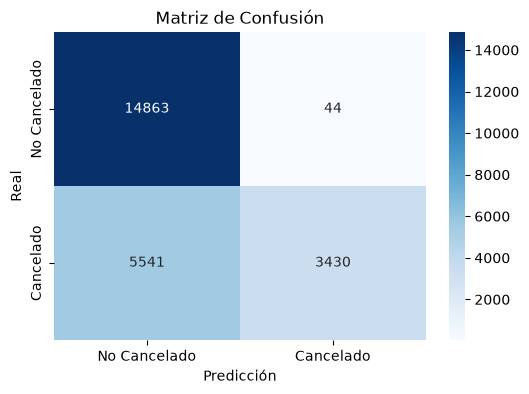

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Cancelado', 'Cancelado'],
            yticklabels=['No Cancelado', 'Cancelado'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

In [14]:
# Inicializamos el modelo de regresión logística y lo entrenamos con los datos de entrenamiento
modelo_lr = LogisticRegression(max_iter=200, random_state=42)
modelo_lr.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_lr.predict(X_test)

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")

mse, rmse, mae, r2 = calcular_metricas_evaluacion(y_pred, y_test)

Accuracy:  0.78
Precisión: 0.89
Recall:    0.47
F1-Score:  0.61

Evaluación del modelo:
MSE (Error cuadrático medio): 0.2215
RMSE (Raíz del error cuadrático medio): 0.4707
MAE (Error absoluto medio): 0.2215
R² (Coeficiente de determinación): 0.0555
El modelo explica aproximadamente el 5.55% de la varianza


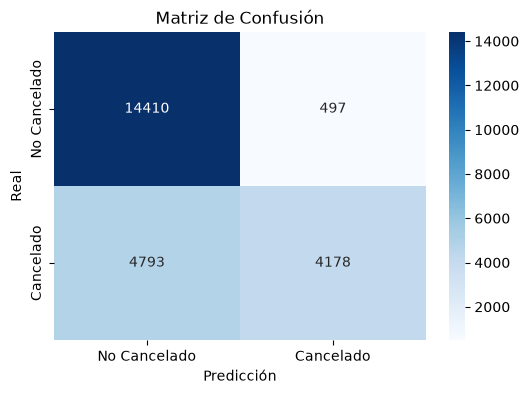

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Cancelado', 'Cancelado'],
            yticklabels=['No Cancelado', 'Cancelado'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()